In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

**Dataset on Github:** https://github.com/tejas79883/Exploratory-Data-Analysis-EDA--Retail-Sales-Data?utm_source=chatgpt.com

**Direct CSV Link:** https://raw.githubusercontent.com/tejas79883/Exploratory-Data-Analysis-EDA--Retail-Sales-Data/main/Retail.csv

In [ ]:
# importing dataset
url="https://raw.githubusercontent.com/tejas79883/Exploratory-Data-Analysis-EDA--Retail-Sales-Data/main/Retail.csv"
data=pd.read_csv(url)

In [ ]:
df=pd.DataFrame(data)

In [ ]:
# show first 5 rows of dataset
df.head()

,OrderNumber,ProductName,Color,Category,Subcategory,ListPrice,Orderdate,Duedate,Shipdate,PromotionName,SalesRegion,OrderQuantity,UnitPrice,SalesAmount,DiscountAmount,TaxAmount,Freight
0,SO43843,"Mountain-100 Silver, 48",Silver,Bikes,Mountain Bikes,3399.9900,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,2039.9940,4079.9880,0.0,326.3990,101.9997
1,SO43843,"Mountain-100 Black, 48",Black,Bikes,Mountain Bikes,3374.9900,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,2024.9940,4049.9880,0.0,323.9990,101.2497
2,SO43843,"HL Mountain Frame - Silver, 46",Silver,Components,Mountain Frames,1204.3248,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,722.5949,1445.1898,0.0,115.6152,36.1297
3,SO43843,"Mountain-100 Black, 44",Black,Bikes,Mountain Bikes,NaN,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,5,2024.9940,10124.9700,0.0,809.9976,253.1243
4,SO43843,"HL Mountain Frame - Silver, 38",Silver,Components,Mountain Frames,1204.3248,1/29/2011,02-10-2011,02-05-2011,No Discount,Central,2,722.5949,1445.1898,0.0,115.6152,36.1297


In [ ]:
# (rows X columns)
df.shape

(32040, 17)

In [ ]:
# all column names within dataset
df.columns

Index(['OrderNumber', 'ProductName', 'Color', 'Category', 'Subcategory',
       'ListPrice', 'Orderdate', 'Duedate', 'Shipdate', 'PromotionName',
       'SalesRegion', 'OrderQuantity', 'UnitPrice', 'SalesAmount',
       'DiscountAmount', 'TaxAmount', 'Freight'],
      dtype='object')

In [ ]:
# generate a quick statistical summary of a dataset
df.describe()

,ListPrice,UnitPrice,SalesAmount,DiscountAmount,TaxAmount,Freight
count,32032.000000,32040.000000,32040.000000,32040.00000,32040.000000,32040.000000
mean,714.663419,424.122103,1299.023131,8.15285,103.921849,32.475594
std,851.623778,506.799303,2153.316625,78.40708,172.265331,53.832916
min,2.290000,1.328200,1.374000,0.00000,0.109900,0.034400
25%,54.990000,32.994000,125.964000,0.00000,10.077100,3.149100
50%,337.220000,202.332000,445.410000,0.00000,35.632800,11.135300
75%,1079.990000,647.994000,1457.820000,0.00000,116.625600,36.445500
max,3578.270000,2146.962000,27893.619000,4005.23760,2231.489500,697.340500


In [ ]:
# used primarily to print a concise summary and structure of a DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32040 entries, 0 to 32039
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderNumber     32040 non-null  object 
 1   ProductName     32040 non-null  object 
 2   Color           29073 non-null  object 
 3   Category        32040 non-null  object 
 4   Subcategory     32040 non-null  object 
 5   ListPrice       32032 non-null  float64
 6   Orderdate       32040 non-null  object 
 7   Duedate         32040 non-null  object 
 8   Shipdate        32040 non-null  object 
 9   PromotionName   32040 non-null  object 
 10  SalesRegion     32025 non-null  object 
 11  OrderQuantity   32026 non-null  object 
 12  UnitPrice       32040 non-null  float64
 13  SalesAmount     32040 non-null  float64
 14  DiscountAmount  32040 non-null  float64
 15  TaxAmount       32040 non-null  float64
 16  Freight         32040 non-null  float64
dtypes: float64(6), object(11)
memor

In [ ]:
# used to count the number of missing (null) values in each column of a DataFrame
df.isnull().sum()

,0
OrderNumber,0
ProductName,0
Color,2967
Category,0
Subcategory,0
ListPrice,8
Orderdate,0
Duedate,0
Shipdate,0
PromotionName,0


Predicting SalesAmount from OrderQuantity. So, taking X = OrderQuantity (input/independent variable) and y = SalesAmount (output/dependent/target variable).

OrderQuantity attribute has **numeric data** but its datatype is **object**. So, we need to change it and also OrderQuantity has **14 null values**.

In [ ]:
df['OrderQuantity'] = pd.to_numeric(df['OrderQuantity'], errors='coerce') # converting from object to numeric datatype
df.dropna(subset=['OrderQuantity'], inplace=True) # drop null values. [Why drop null values? Because only 14 rows have null values out of 32040 rows which is 0.043% of dataset.]

# defining input and target
X = df[['OrderQuantity']] # Because scikit-learn expects X (input/features) to be 2D, even when you have only one feature.
y = df['SalesAmount'] # creates a single column/Series containing what we want to predict.

In [ ]:
df.isnull().sum() # checking for null values

,0
OrderNumber,0
ProductName,0
Color,2967
Category,0
Subcategory,0
ListPrice,8
Orderdate,0
Duedate,0
Shipdate,0
PromotionName,0


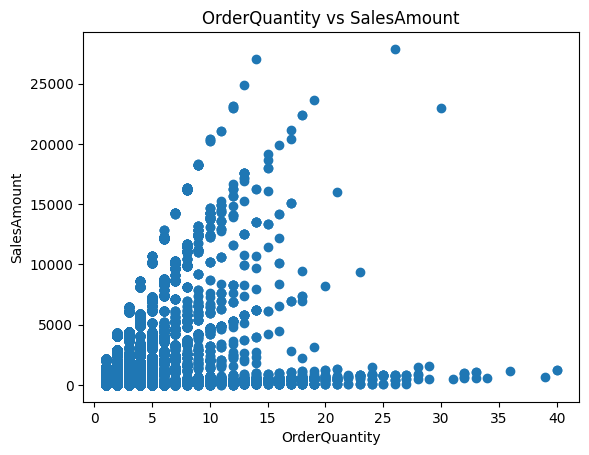

In [ ]:
# plotting OrderQuantity and SalesAmount
plt.scatter(X, y)
plt.xlabel('OrderQuantity')
plt.ylabel('SalesAmount')
plt.title('OrderQuantity vs SalesAmount')

plt.show()

We don't want to train and test our model using exactly the same data. So, We divide the dataset into two parts:

**Training data**: Used to teach the model.
***80% → training***

**Testing data**: Used to check whether the model learned properly
***20% → testing***

In [ ]:
# train_test_split(): randomly divides the data
# random_state=42 tells Python to use the same random selection every time [means this number has no specific meaning and it does effect by high or low value but every time we change the number we get different shuffle and if provide same value then get same shuffle everytime]
# test_size = 0.2 means 20% test data

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Below we're creating a Linear Regression model. Think of model as an empty machine that hasn't learned anything yet

In [ ]:
# creating linear regression model
model = LinearRegression()

Now give the training data to the model. This is where the model learns the relationship between: **OrderQuantity → SalesAmount**

This is where the machine learning happens. You're basically saying: "**Look at these input values (X_train) and their corresponding answers (y_train) and learn the relationship between them.**"

The model tries to find the best coefficients for an equation like:

 **y = b₀ + b₁X**

**SalesAmount = b₀ + b₁ * OrderQuantity**

The model calculates the b values automatically.

**LinearRegression()** finds the coefficients (b₀ and b₁) using a **least-squares method** (based on solving the linear algebra problem directly), rather than iteratively updating them with gradient descent. If you specifically want to use Gradient Descent, you can use **SGDRegressor()**.

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# values of bo and b1
print("Value of b0:",model.intercept_)
print("Value of b1:",model.coef_)

Value of b0: 736.6875071797284
Value of b1: [151.93800062]


In [ ]:
# testing model with 20% test data
y_pred = model.predict(X_test)

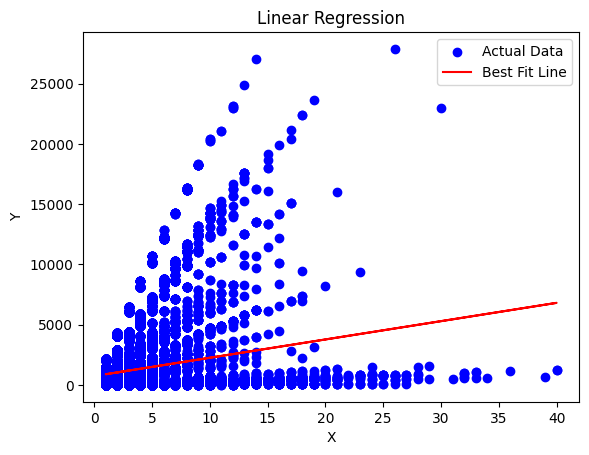

In [ ]:
# Draw the original data points and best-fit line
plt.scatter(X, y, color="blue", label="Actual Data")

plt.plot(X, model.predict(X), color="red", label="Best Fit Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()

plt.show()

**Q. y_test data is useless ?
No, it is used to compare with y_pred**

X_test → questions given to the model

y_test → correct answers that we already know

y_pred → answers predicted by the model

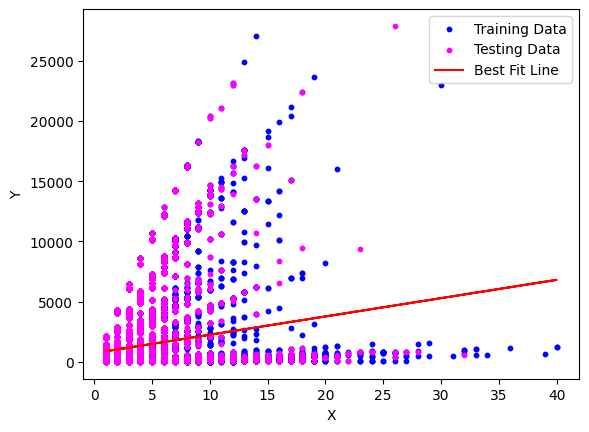

In [ ]:
plt.scatter(X_train, y_train, color="blue", s=10, label="Training Data")
plt.scatter(X_test, y_test, color="magenta", s=10, label="Testing Data")

plt.plot(X, model.predict(X), color="red", label="Best Fit Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
# comparing actual vs predicted y
results = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})

results.head()

,Actual,Predicted
12342,115.3616,1344.439510
4057,1229.4589,888.625508
22207,48.5940,888.625508
16319,1717.8000,1040.563508
25691,291.5460,2104.129513
